In [1]:
import matplotlib.pyplot as plt

import pydpeet as eet

eet.set_logging_style("ERROR")

# Table of Content

1. [Convert](#convert)
2. [Merge](#Merge)
3. [Sequence](#seqence)
4. [add SOC](#soc)
5. [add Capacity](#capacity)
6. Internal Resistance
7. [SOH-C/SOH-R](#soh)
8. [OCV/DVA/ICA](#ocv)


## Convert

In [2]:
df = eet.convert(config="neware_8_0_0_516", input_path=r"..\..\res\raw\Cal_Ageing_Checkup1.xlsx")
df.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A]
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None
1.0,None,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None
2.0,None,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None
3.0,None,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None
4.0,None,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None


## Merge

In [3]:
dfs = eet.convert(config="neware_8_0_0_516", input_path=r"..\..\res\raw")

In [4]:
# fig, ax = plt.subplots(1,len(Datas), figsize=(10,5))
# ax = ax.flatten()
# for i, (data, ax_i) in enumerate(zip(Datas, ax)):
#     data.plot(x="Absolute Time[yyyy-mm-dd hh:mm:ss]", y="Voltage[V]", ax=ax_i)
#     ax_i.set_title(f"Test {i+1}")
#     ax_i.set_ylabel("Voltage[V]")
#     ax_i.set_xlabel("Absolute Time")

In [5]:
merged_dfs = eet.merge_into_series(dfs)
merged_dfs.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],TestIndex
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,0.0
1,NaN,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,0.0
2,NaN,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,0.0
3,NaN,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,0.0
4,NaN,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,0.0


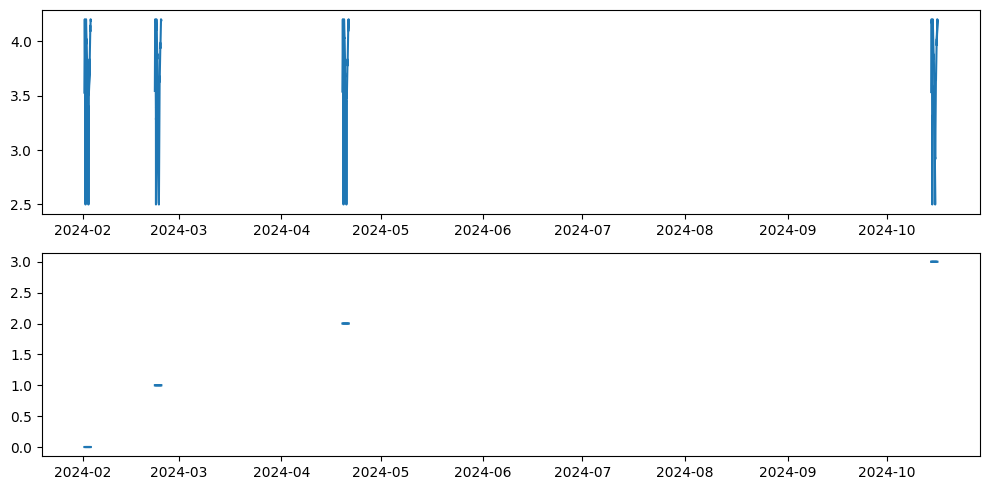

In [6]:
import matplotlib as mpl

mpl.rcParams["agg.path.chunksize"] = 20000  # z.B. 10k–100k ausprobieren
mpl.rcParams["path.simplify"] = True
mpl.rcParams["path.simplify_threshold"] = 1.0


fig, ax = plt.subplots(2, figsize=(10, 5))
ax[0].plot(merged_dfs["Date_Time"], merged_dfs["Voltage[V]"])
ax[1].plot(merged_dfs["Date_Time"], merged_dfs["TestIndex"])
fig.tight_layout()
plt.show()

## Seqence

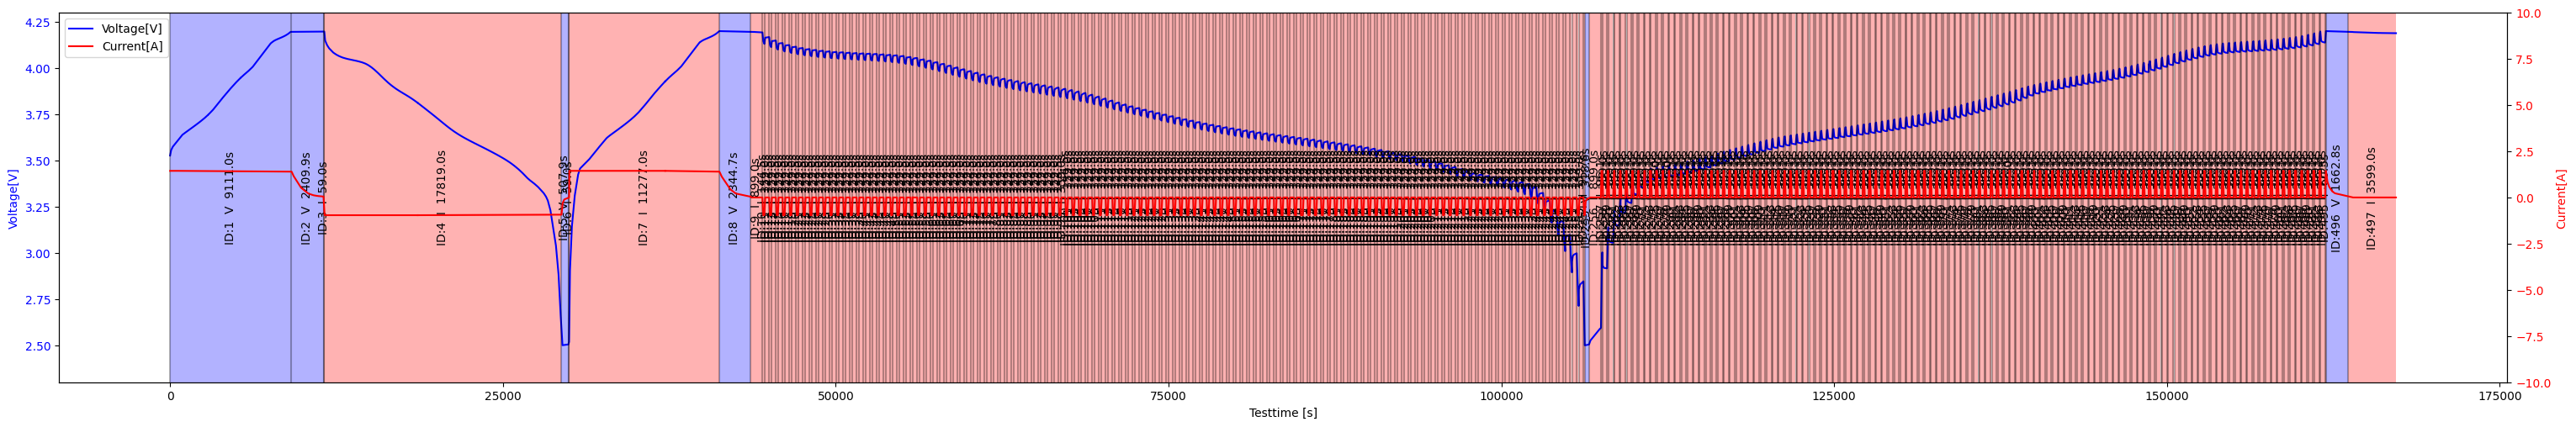

In [7]:
sequenced_df = eet.add_primitive_segments(df)

eet.visualize_phases(
    dataframe=sequenced_df,
    # ...
)
plt.show()

## SOC

In [8]:
# Battery_Config = eet.process.analyze.am23nmc


# todo: is it possible to probide acces to the Batemo database and fetch battery configs directly from there?
# todo: or we download it and provide the databse directly?

eet.add_soc(df, sequenced_df, standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY, config=eet.lgm50lt_nmc_4800)

C:\Users\m_ott\AppData\Local\Temp\ipykernel_9224\3228317804.py:7: UserWarning: Column 'Capacity[Ah]' missing, adding with function add_capacity.
  eet.add_soc(df, sequenced_df, standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY, config=eet.lgm50lt_nmc_4800)


,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],Capacity[Ah],SOC
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,NaN,0.183914
1.0,None,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,NaN,0.183998
2.0,None,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,NaN,0.184081
3.0,None,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,NaN,0.184164
4.0,None,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,NaN,0.184248
...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,None,515,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN,1.000000
NaN,None,516,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN,1.000000
NaN,None,517,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN,1.000000
NaN,None,518,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN,1.000000


## Capacity

In [9]:
eet.add_capacity(df, sequenced_df, neware_bool=True, config=eet.lgm50lt_nmc_4800)
# plot

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],Capacity[Ah]
0.0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,NaN
1.0,None,0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,NaN
2.0,None,0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,NaN
3.0,None,0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,NaN
4.0,None,0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,None,515,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN
NaN,None,516,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN
NaN,None,517,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN
NaN,None,518,NaN,NaN,NaN,NaN,NaT,None,None,None,None,NaN


## SOH

In [10]:
# Not yet implemented!
# eet.add_soh(df=df, merged_dfs=sequenced_df, config=eet.lgm50lt_nmc_4800, method="C")

In [11]:
# Not yet implemented!
# eet.add_soh(df, sequenced_df, method="R")

## OCV

C:\Users\m_ott\Documents\Bildung\2022-xxxx_TU-Berlin_WiMi\Projekte\2025_PyDPEET\Git\pydpeet\src\pydpeet\process\analyze\extract\ocv.py:96: UserWarning: Column 'Capacity[Ah]' missing, adding with function add_capacity.
  df_primitives = add_soc(


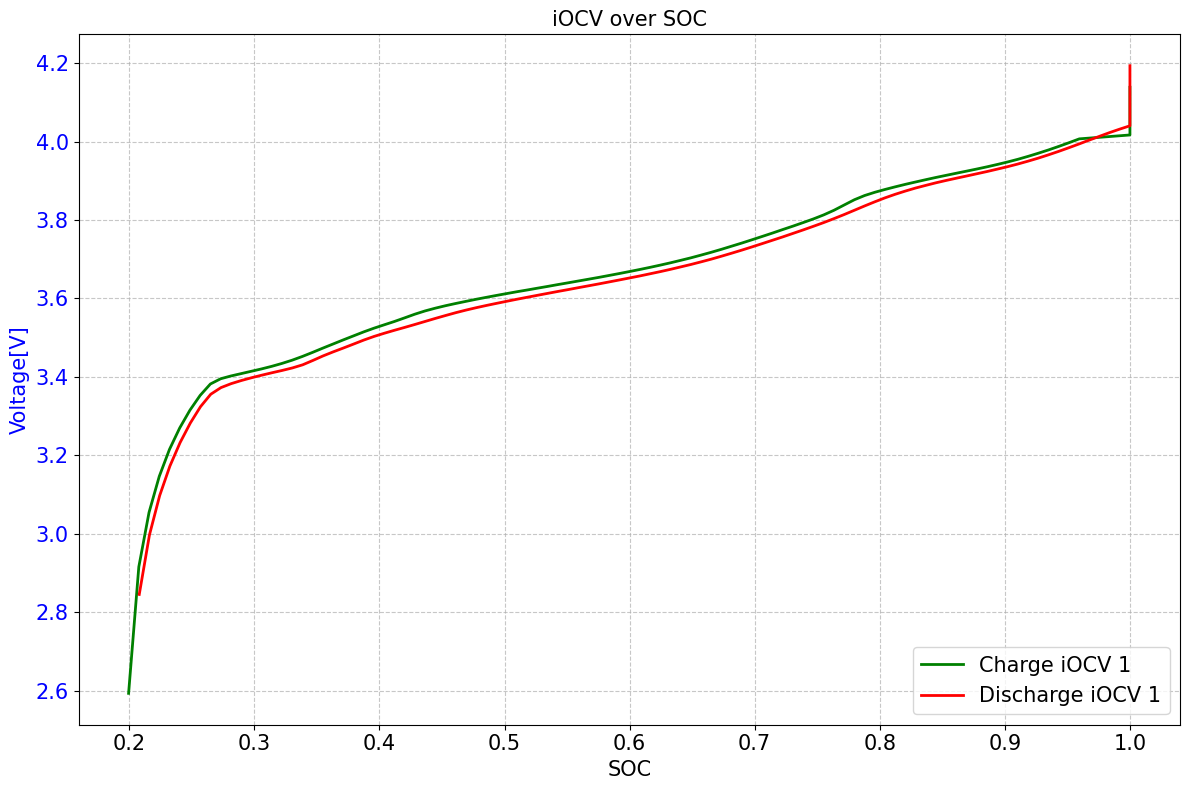

In [12]:
ocv_data = eet.extract_ocv_iocv(df=df, config=eet.lgm50lt_nmc_4800)